In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from  scipy.stats import norm, t
from math import sqrt
import seaborn as sns


# Análisis Exploratorio Inicial: Visión General del Dataset

In [ ]:
df = pd.read_parquet('../data/processed/fide_players_all.parquet')
df.head(10)

,fideid,name,country,sex,title,w_title,o_title,rating,rapid_rating,blitz_rating,birthday,flag
0,537001345,A Arbhin Vanniarajan,IND,M,nt,nt,nt,1450,1500,1431,2018,a
1,10245154,"A B M Jobair, Hossain",BAN,M,nt,nt,nt,1715,1738,1748,1998,a
2,558074015,A Bala Phani Prabhanjan,IND,M,nt,nt,nt,1585,1553,1524,2012,a
3,12457558,A Bu Ba Co,VIE,M,nt,nt,nt,0,1638,0,2002,a
4,25121731,A C J John,IND,M,nt,nt,nt,1438,0,0,1987,i
5,577037626,A C Jayaraghavan,IND,M,nt,nt,nt,1406,1407,0,2012,a
6,35077023,A Chakravarthy,IND,M,nt,nt,nt,1491,0,0,1986,i
7,537070436,A Darshil,IND,M,nt,nt,nt,1489,1609,1542,2013,a
8,10207538,"A E M, Doshtagir",BAN,M,nt,nt,nt,1904,1902,1916,1974,i
9,532004656,"A F M Ehteshamul, Hoque (tuhin",BAN,M,nt,nt,nt,1859,1760,0,1977,a


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785987 entries, 0 to 785986
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   fideid        785987 non-null  string  
 1   name          785987 non-null  string  
 2   country       785987 non-null  category
 3   sex           785987 non-null  category
 4   title         785987 non-null  category
 5   w_title       785987 non-null  category
 6   o_title       785987 non-null  category
 7   rating        785987 non-null  Int64   
 8   rapid_rating  785987 non-null  Int64   
 9   blitz_rating  785987 non-null  Int64   
 10  birthday      776189 non-null  Int64   
 11  flag          785987 non-null  category
dtypes: Int64(4), category(6), string(2)
memory usage: 63.8 MB


## Distribucion de elo global

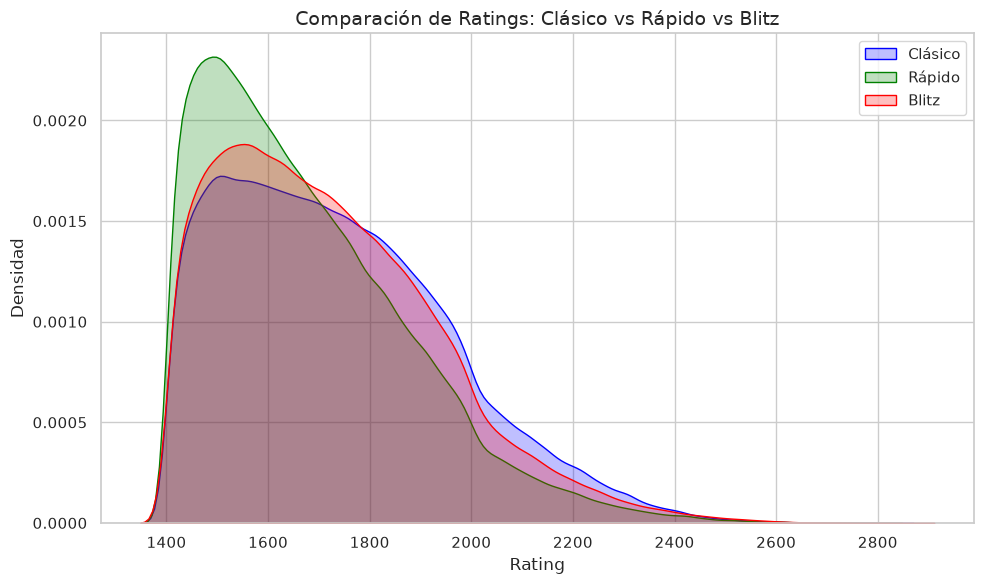

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


sns.kdeplot(df[df['rating'] > 0]['rating'], fill=True, color='blue', label='Clásico')
sns.kdeplot(df[df['rapid_rating'] > 0]['rapid_rating'], fill=True, color='green', label='Rápido')
sns.kdeplot(df[df['blitz_rating'] > 0]['blitz_rating'], fill=True, color='red', label='Blitz')

plt.title('Comparación de Ratings: Clásico vs Rápido vs Blitz', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

plt.legend()


plt.tight_layout()
plt.show()

## COnteo de jugadores globales

In [ ]:
federaciones = df['country'].value_counts().rename_axis('federacion').reset_index(name='conteo')
federaciones['proporcion'] = federaciones['conteo'] / federaciones['conteo'].sum()
federaciones['porcentaje'] = np.round(federaciones['proporcion'],3) * 100

federaciones.head(10)

,federacion,conteo,proporcion,porcentaje
0,IND,72292,0.091976,9.2
1,RUS,71509,0.090980,9.1
2,FRA,52434,0.066711,6.7
3,ESP,43942,0.055907,5.6
4,GER,40251,0.051211,5.1
5,IRI,32925,0.041890,4.2
6,POL,29409,0.037417,3.7
7,ITA,21360,0.027176,2.7
8,BRA,17383,0.022116,2.2
9,UKR,13988,0.017797,1.8


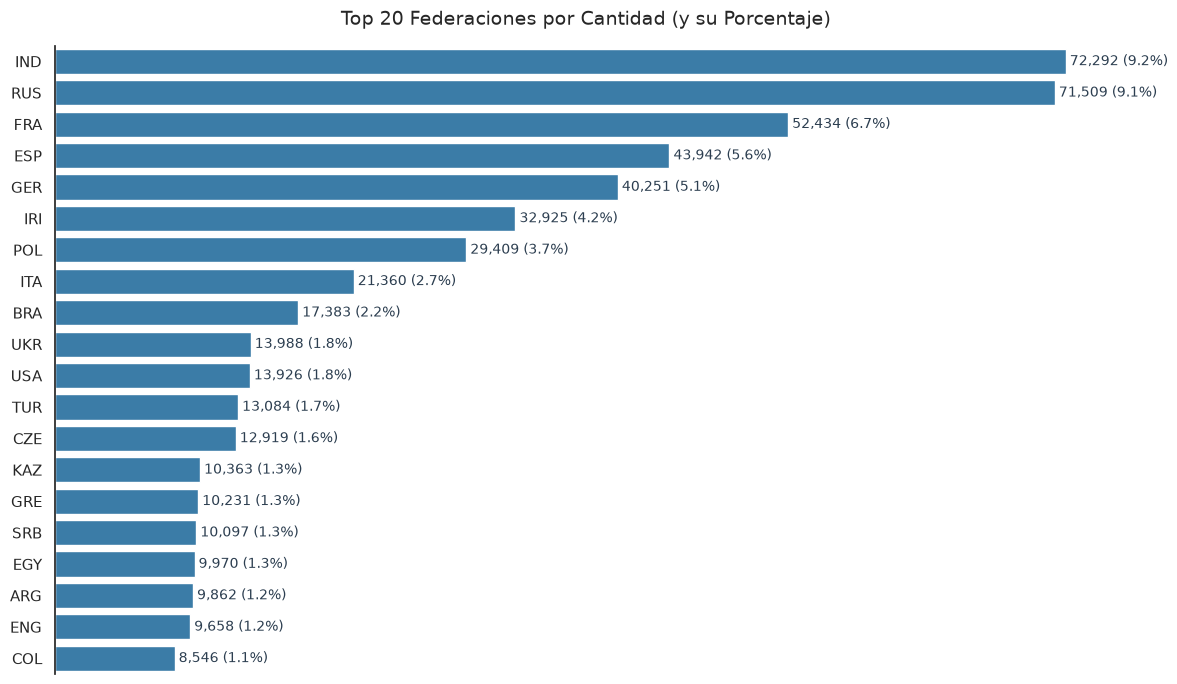

In [ ]:

federaciones = df['country'].value_counts().rename_axis('federacion').reset_index(name='conteo')
federaciones['proporcion'] = federaciones['conteo'] / federaciones['conteo'].sum()
federaciones['porcentaje'] = np.round(federaciones['proporcion'], 4) 

top_15 = federaciones.head(20)


sns.set_theme(style="white") 


fig, ax = plt.subplots(figsize=(12, 7))


sns.barplot(
    data=top_15, 
    x='conteo', 
    y='federacion', 
    color='#2980b9',
    order=top_15['federacion'],
    ax=ax
)


ax.set_title('Top 20 Federaciones por Cantidad (y su Porcentaje)', fontsize=14, pad=15)
ax.set_ylabel('') 
ax.set_xlabel('') 
ax.xaxis.set_visible(False) 


sns.despine(bottom=True) 


for i, barra in enumerate(ax.patches):
    ancho = barra.get_width()
    pct = top_15['porcentaje'].iloc[i] 
    
    texto = f' {int(ancho):,} ({pct*100:.1f}%)' 
    
    ax.text(
        ancho,                           
        barra.get_y() + barra.get_height() / 2, 
        texto,
        ha='left', va='center', fontsize=10, color='#2c3e50'
    )

fig.tight_layout()
plt.show()


## Conteo de titulos globales

In [ ]:
titulos = df['title'].value_counts().rename_axis('titulos').reset_index(name='conteo')
titulos['proporcion'] = titulos['conteo'] / titulos['conteo'].sum()
titulos['porcentaje'] = titulos['proporcion']


titulos

,titulos,conteo,proporcion,porcentaje
0,nt,761319,0.968615,0.968615
1,FM,9765,0.012424,0.012424
2,IM,4304,0.005476,0.005476
3,CM,3841,0.004887,0.004887
4,WFM,2218,0.002822,0.002822
5,GM,1899,0.002416,0.002416
6,WCM,1362,0.001733,0.001733
7,WIM,935,0.001190,0.001190
8,WGM,344,0.000438,0.000438


## Conteo de titulos por Federacion

In [ ]:



titulos_FED = (
    pd.crosstab(index=df['country'], columns=df['title'])
    .assign(Total=lambda x: x.sum(axis=1))   
    .sort_values(by='Total', ascending=False) 
    .reset_index()                            
)

titulos_FED.columns.name = None \

nuevo_orden = [
    'country', 
    'GM', 'IM', 'FM', 'CM',      
    'WGM', 'WIM', 'WFM', 'WCM',  
    'nt',                       
    'Total'                      
]

titulos_FED = titulos_FED[nuevo_orden]

titulos_FED .head(10)

,country,GM,IM,FM,CM,WGM,WIM,WFM,WCM,nt,Total
0,IND,96,171,194,169,15,46,79,73,71449,72292
1,RUS,184,485,1251,101,39,100,402,38,68909,71509
2,FRA,60,133,299,96,9,19,36,6,51776,52434
3,ESP,60,151,470,219,3,15,57,10,42957,43942
4,GER,103,301,993,210,22,38,93,17,38474,40251
5,IRI,16,28,89,33,2,9,19,14,32715,32925
6,POL,56,122,242,131,13,30,66,39,28710,29409
7,ITA,18,52,194,38,1,4,18,4,21031,21360
8,BRA,15,34,122,64,0,8,14,17,17109,17383
9,UKR,85,188,207,28,19,30,37,4,13390,13988


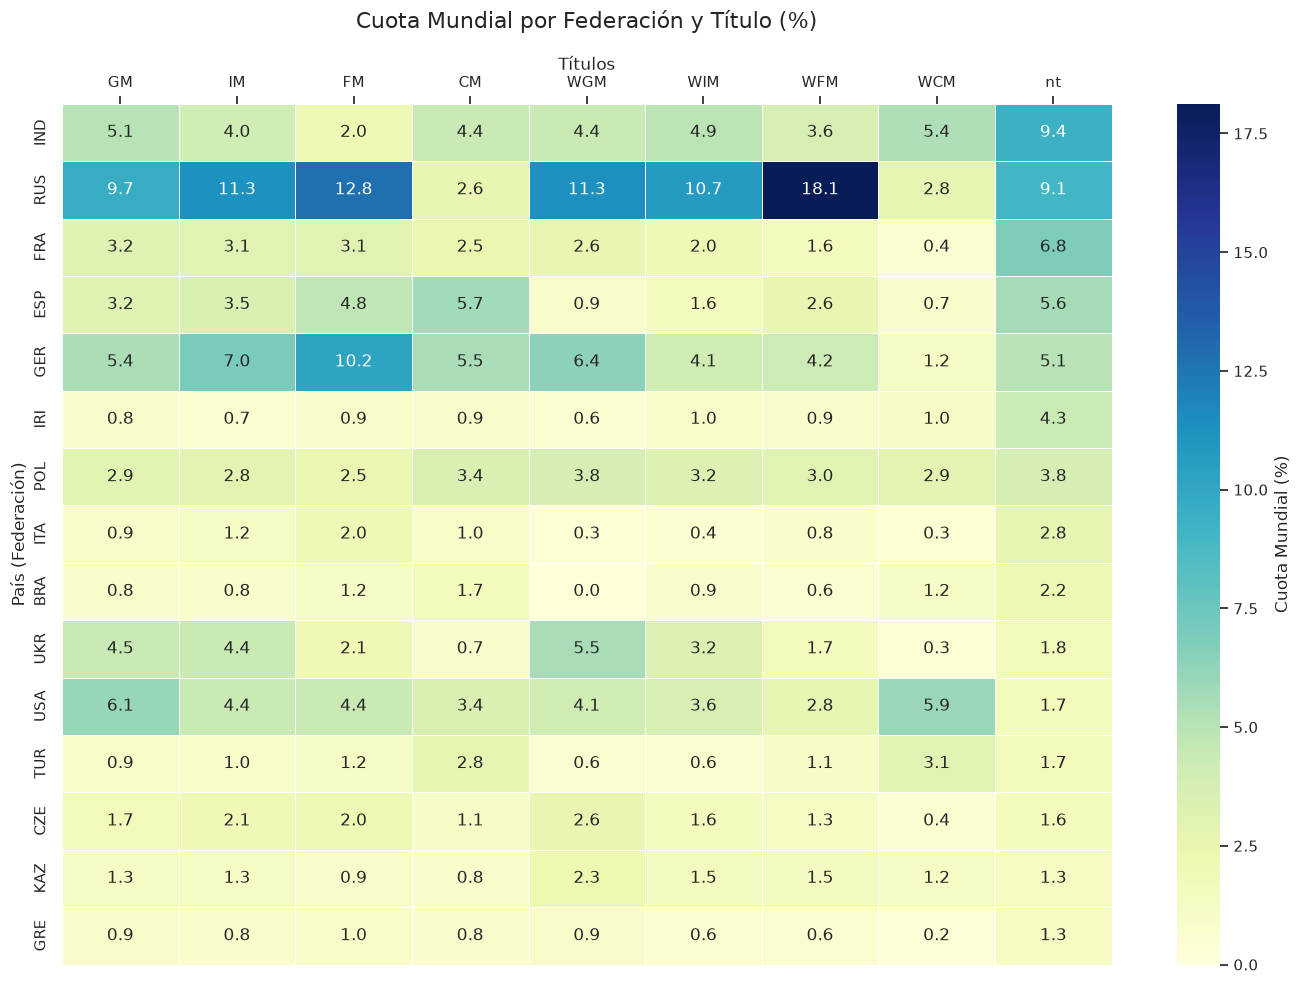

In [ ]:

titulos_con_nt = ['GM', 'IM', 'FM', 'CM', 'WGM', 'WIM', 'WFM', 'WCM', 'nt']
df_plot_completo = titulos_FED.head(15)[['country'] + titulos_con_nt].set_index('country')
totales_mundiales = titulos_FED[titulos_con_nt].sum()
df_plot_cuota_mundial = (df_plot_completo.div(totales_mundiales, axis=1)) * 100

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(df_plot_cuota_mundial, cmap="YlGnBu", annot=True, fmt=".1f", 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Cuota Mundial (%)'})

ax.set_title("Cuota Mundial por Federación y Título (%)", fontsize=16, pad=20)
ax.set_xlabel("Títulos", fontsize=12)
ax.set_ylabel("País (Federación)", fontsize=12)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
plt.tight_layout()
plt.show()

